In [1]:
from pathlib import Path

In [2]:
import gplately

/Users/jianpingzhou/miniconda3/envs/plate/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
/Users/jianpingzhou/miniconda3/envs/plate/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [3]:
from plate_model_manager import PlateModelManager
from sklearn.cluster import DBSCAN
from pathlib import Path
import matplotlib as mpl
from scipy.stats import gaussian_kde
from shapely.geometry import MultiPoint
from pyproj import CRS, Transformer

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
from sklearn.neighbors import BallTree
from scipy.spatial import ConvexHull
from scipy.stats import gaussian_kde

##### PLOT EXPORT SETTINGS

In [5]:
########
export_dir = "/Users/jianpingzhou/work/Papers/Geology/Geology/revision/DBSCAN_maps" # change to your local file path

def export_plot(fig, name, dpi=300, save_svg=True, save_pdf=True, save_png=True):
    """
    Save figure for publication + quick-look usage.
    Does NOT modify the figure content.
    """
    Path(export_dir).mkdir(parents=True, exist_ok=True)

    # ensure editable text in Illustrator / journal-safe fonts
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype']  = 42
    mpl.rcParams['svg.fonttype'] = 'none'

    if save_pdf:
        fig.savefig(f"{export_dir}/{name}.pdf", dpi=dpi, bbox_inches="tight")
    if save_svg:
        fig.savefig(f"{export_dir}/{name}.svg", dpi=dpi, bbox_inches="tight")
    if save_png:
        fig.savefig(f"{export_dir}/{name}.png", dpi=450, bbox_inches="tight")

    print(f"Exported: {name}")

##### 0) USER SETTINGS (DEFINE ONCE, USED EVERYWHERE)

In [6]:

file_path = "/Users/jianpingzhou/work/Papers/Geology/Geology/revision/dataset/Global_crustal_thickness_with_paleo_coords.csv"

##### Define reconstruction time (time window)

In [7]:
reconstruction_time = 100   # Ma
window = 50                  # Myr
t_min = reconstruction_time
t_max = reconstruction_time + window

##### ***Important*** Set sample elevation allowance

In [8]:
prob_threshold = 0.7

#### Elevation-coloured dots + P2/P3/P45 DBSCAN overlays + P45 centroid stars

#### FIXED SPATIAL SCALES (apply to P2, P3, P45)

In [9]:
thin_km = 75
support_radius_km = 300
eps_km = 900
min_samples = 3
earth_radius_km = 6371.0

#### WHICH LEVELS TO MAP

In [10]:
LEVEL_FOOTPRINT = "P2_km"     # ≥2 km domain
LEVEL_MID       = "P3_km"     # ≥3 km mid (optional overlay)
LEVEL_CORE      = "P45_km"    # ≥4.5 km core

In [11]:
# OPTIONAL MID-LEVEL (P3) OVERLAY

In [12]:
SHOW_P3_LAYER   = True
SHOW_P3_LABELS  = False
P3_COLOR        = "#f4a261"
P3_ALPHA        = 0.22
P3_SIZE_SCALE   = 1600
P3_EXCLUDE_P45  = False

In [13]:
# VISUALISATION MODES FOR P45

In [14]:
SHOW_P45_POINTS      = True
SHOW_P45_INFLUENCE   = False
SHOW_P45_HULLS       = True
SHOW_P45_KDE         = False

In [15]:
# ELEVATION DOT DISPLAY

In [16]:
SHOW_ELEVATION_DOTS = True
DOT_SIZE = 90
DOT_LINEWIDTH = 0.25

# fixed elevation colour scale
E_VMIN = 0.0
E_VMAX = 6.0

# elevation colormap
base_cmap = plt.cm.terrain
colors = base_cmap(np.linspace(0.35, 1.0, 256))
elev_cmap = LinearSegmentedColormap.from_list("highland", colors)

#### 1) LOAD PLATE MODEL

In [17]:
pm_manager = PlateModelManager()
cao2024_model = pm_manager.get_model("Cao2024", data_dir="plate-model-repo")

rotation_model = cao2024_model.get_rotation_model()
topology_features = cao2024_model.get_topologies()
static_polygons = cao2024_model.get_static_polygons()

coastlines = cao2024_model.get_layer("Coastlines")
continents = cao2024_model.get_layer("ContinentalPolygons")
COBs = cao2024_model.get_layer("COBs")

model = gplately.PlateReconstruction(rotation_model, topology_features, static_polygons)
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

#### 2) LOAD DATA

In [18]:
pct_data = pd.read_csv(file_path)

In [19]:
# 3) BUILD PROBABILITIES FROM (z0, Elevation) ENVELOPE

def add_elevation_probabilities(df, n_draws=300, sampler="triangular", thresholds=(2.0, 3.0, 4.5)):
    zmin = df["z0_min_km"].to_numpy(dtype=float)
    zmid = df["z0_mid_km"].to_numpy(dtype=float)
    zmax = df["z0_max_km"].to_numpy(dtype=float)

    E_low  = df["Elev_abs_low_km"].to_numpy(dtype=float)
    E_mid  = df["Isostatic_Elevation_absolute_km"].to_numpy(dtype=float)
    E_high = df["Elev_abs_high_km"].to_numpy(dtype=float)

    rng = np.random.default_rng(0)
    probs = {thr: np.full(len(df), np.nan, dtype=float) for thr in thresholds}

    for i in range(len(df)):
        if not (np.isfinite(zmin[i]) and np.isfinite(zmid[i]) and np.isfinite(zmax[i])):
            continue
        if not (np.isfinite(E_low[i]) and np.isfinite(E_mid[i]) and np.isfinite(E_high[i])):
            continue

        if sampler == "uniform":
            z0 = rng.uniform(zmin[i], zmax[i], size=n_draws)
        else:
            if (zmax[i] > zmin[i]) and (zmax[i] >= zmid[i] >= zmin[i]):
                z0 = rng.triangular(zmin[i], zmid[i], zmax[i], size=n_draws)
            else:
                z0 = np.full(n_draws, zmid[i])

        elev = np.interp(z0, [zmin[i], zmid[i], zmax[i]], [E_low[i], E_mid[i], E_high[i]])

        for thr in thresholds:
            probs[thr][i] = np.mean(elev >= thr)

    df["P2_km"]  = probs[2.0]
    df["P3_km"]  = probs[3.0]
    df["P45_km"] = probs[4.5]
    return df

if not all(c in pct_data.columns for c in ["P2_km", "P3_km", "P45_km"]):
    pct_data = add_elevation_probabilities(pct_data)

In [20]:
# 4) TIME WINDOW FILTER

In [21]:
time_mask = (pct_data["Age_Min"] <= t_max) & (pct_data["Age_Max"] >= t_min)
slice_data = pct_data.loc[time_mask].copy()
print(f"Time-window samples (raw): {len(slice_data)}")

Time-window samples (raw): 11128


In [22]:
# 5) ENSURE RECONSTRUCTED COORDS EXIST

In [23]:
need_recon = (
    ("rlat" not in slice_data.columns) or ("rlon" not in slice_data.columns)
    or slice_data["rlat"].isna().any() or slice_data["rlon"].isna().any()
)

if need_recon:
    gpts = gplately.Points(
        model,
        slice_data["Lon"].to_numpy(dtype=float),
        slice_data["Lat"].to_numpy(dtype=float),
    )
    rlons, rlats = gpts.reconstruct(reconstruction_time, return_array=True)
    slice_data["rlon"] = rlons
    slice_data["rlat"] = rlats

finite_recon = np.isfinite(slice_data["rlat"].to_numpy()) & np.isfinite(slice_data["rlon"].to_numpy())
slice_data = slice_data.loc[finite_recon].copy()
print(f"Reconstructable samples: {len(slice_data)} / {time_mask.sum()}")

Reconstructable samples: 11128 / 11128


In [24]:
# 6) CLASSIFICATION USING PROBABILITIES

In [25]:
P2  = slice_data["P2_km"].to_numpy(float)
P3  = slice_data["P3_km"].to_numpy(float)
P45 = slice_data["P45_km"].to_numpy(float)

oro_definite = P2 >= 0.7
oro_possible = (P2 >= 0.3) & (P2 < 0.7)

plat_definite = P3 >= 0.7
plat_possible = (P3 >= 0.3) & (P3 < 0.7)

ext_definite = P45 >= 0.7
ext_possible = (P45 >= 0.3) & (P45 < 0.7)

E_mid  = slice_data["Isostatic_Elevation_absolute_km"].to_numpy(float)
E_low  = slice_data["Elev_abs_low_km"].to_numpy(float)
E_high = slice_data["Elev_abs_high_km"].to_numpy(float)
uncertainty = E_high - E_low

# transparency from uncertainty
alpha_all = np.clip(1 - uncertainty / 4.0, 0.45, 1.0)

# ===============================================================
# CORE PIPELINE: bias-aware thinning + DBSCAN for one level
# ===============================================================
def run_biasaware_dbscan(slice_df: pd.DataFrame, level_col: str) -> pd.DataFrame:
    if level_col not in slice_df.columns:
        raise KeyError(f"Missing {level_col} in slice_data columns.")

    # probability filter
    df = slice_df.loc[slice_df[level_col].astype(float) >= prob_threshold].copy()
    print(f"Samples passing {level_col} >= {prob_threshold}: {len(df)}")

    # collapse to unique paleo-locations
    df["rlat_r"] = df["rlat"].round(3)
    df["rlon_r"] = df["rlon"].round(3)

    agg = {
        "rlat": "first",
        "rlon": "first",
        "Age_Min": "min",
        "Age_Max": "max",
        "Isostatic_Elevation_absolute_km": "mean",
        "Elev_abs_low_km": "mean",
        "Elev_abs_high_km": "mean",
    }
    for col in ["P2_km", "P3_km", "P45_km"]:
        if col in df.columns:
            agg[col] = "mean"

    df = df.groupby(["rlat_r", "rlon_r"]).agg(agg).reset_index(drop=True)
    print(f"Collapsed → {len(df)} unique paleo-locations")

    # spatial weighting
    coords_all = np.radians(np.vstack([df["rlat"].to_numpy(float), df["rlon"].to_numpy(float)]).T)
    tree_all = BallTree(coords_all, metric="haversine")

    support_rad = support_radius_km / earth_radius_km
    counts = tree_all.query_radius(coords_all, r=support_rad, count_only=True)
    df["spatial_weight"] = 1.0 / np.maximum(counts, 1)
    print(f"Mean neighbour count within {support_radius_km} km: {counts.mean():.2f}")

    # aggregation-based thinning
    thin_rad = thin_km / earth_radius_km
    visited = np.zeros(len(df), dtype=bool)
    thin_records = []

    for i in range(len(df)):
        if visited[i]:
            continue

        idx = tree_all.query_radius(coords_all[i:i+1], r=thin_rad)[0]
        visited[idx] = True
        local = df.iloc[idx]

        # combined probability
        P_vals = local[level_col].to_numpy(dtype=float)
        P_comb = 1.0 - np.prod(1.0 - P_vals)

        lat_rep = np.average(local["rlat"])
        lon_rep = np.average(local["rlon"])
        weight_rep = np.sum(local["spatial_weight"])
        elev_rep = np.average(local["Isostatic_Elevation_absolute_km"])
        low_rep  = np.average(local["Elev_abs_low_km"])
        high_rep = np.average(local["Elev_abs_high_km"])

        thin_records.append({
            "rlat": lat_rep,
            "rlon": lon_rep,
            level_col: P_comb,
            "spatial_weight": weight_rep,
            "Isostatic_Elevation_absolute_km": elev_rep,
            "Elev_abs_low_km": low_rep,
            "Elev_abs_high_km": high_rep,
        })

    thin_df = pd.DataFrame(thin_records)

    # diagnostic: how many raw points merged into each retained node?
    merged_counts = []
    for rec in thin_records:
        rep_coord = np.radians([[rec["rlat"], rec["rlon"]]])
        idx = tree_all.query_radius(rep_coord, r=thin_rad)[0]
        merged_counts.append(len(idx))
    thin_df["merged_n"] = merged_counts

    print(f"After thinning to ~{thin_km} km resolution: {len(thin_df)} points")
    if len(merged_counts) > 0:
        print(f"Mean samples merged per retained node: {np.mean(merged_counts):.2f}")
        print(f"Median samples merged per retained node: {np.median(merged_counts):.1f}")
        print(f"Max samples merged into a single node: {np.max(merged_counts)}")
        print("90th percentile merged:", np.percentile(merged_counts, 90))
        print("95th percentile merged:", np.percentile(merged_counts, 95))

    coords_thin = np.radians(np.vstack([thin_df["rlat"].to_numpy(float), thin_df["rlon"].to_numpy(float)]).T)

    # DBSCAN
    eps_rad = eps_km / earth_radius_km
    db = DBSCAN(
        eps=eps_rad,
        min_samples=min_samples,
        metric="haversine",
        algorithm="ball_tree",
    ).fit(coords_thin)

    thin_df["cluster_id"] = db.labels_
    thin_df["cluster_id_plot"] = db.labels_

    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    noise_frac = np.mean(db.labels_ == -1)
    print(f"Detected clusters: {n_clusters}")
    print(f"Noise fraction: {noise_frac:.2f}")

    if len(thin_df) > 1:
        ttree = BallTree(coords_thin, metric="haversine")
        dist, _ = ttree.query(coords_thin, k=2)
        mean_nn = np.mean(dist[:, 1]) * earth_radius_km
        print(f"Mean nearest-neighbour spacing (thinned): {mean_nn:.1f} km")

    return thin_df

In [26]:
# RUN LEVELS

In [27]:
print("\n=== P2 (footprint) ===")
dbscan_thin_P2 = run_biasaware_dbscan(slice_data, LEVEL_FOOTPRINT)

if P3_EXCLUDE_P45:
    slice_data_P3 = slice_data.loc[
        (slice_data[LEVEL_MID].astype(float) >= prob_threshold) &
        (slice_data[LEVEL_CORE].astype(float) < prob_threshold)
    ].copy()
else:
    slice_data_P3 = slice_data

print("\n=== P3 (mid) ===")
dbscan_thin_P3 = run_biasaware_dbscan(slice_data_P3, LEVEL_MID)

print("\n=== P45 (core) ===")
dbscan_thin_P45 = run_biasaware_dbscan(slice_data, LEVEL_CORE)


=== P2 (footprint) ===
Samples passing P2_km >= 0.7: 4149
Collapsed → 1403 unique paleo-locations
Mean neighbour count within 300 km: 49.45
After thinning to ~75 km resolution: 343 points
Mean samples merged per retained node: 7.43
Median samples merged per retained node: 3.0
Max samples merged into a single node: 81
90th percentile merged: 18.0
95th percentile merged: 35.799999999999955
Detected clusters: 15
Noise fraction: 0.05
Mean nearest-neighbour spacing (thinned): 161.0 km

=== P3 (mid) ===
Samples passing P3_km >= 0.7: 1756
Collapsed → 594 unique paleo-locations
Mean neighbour count within 300 km: 24.57
After thinning to ~75 km resolution: 203 points
Mean samples merged per retained node: 4.43
Median samples merged per retained node: 2.0
Max samples merged into a single node: 42
90th percentile merged: 9.0
95th percentile merged: 14.0
Detected clusters: 10
Noise fraction: 0.07
Mean nearest-neighbour spacing (thinned): 241.3 km

=== P45 (core) ===
Samples passing P45_km >= 0.7:

In [28]:
# BUILD P45 SUMMARY TABLE FOR CENTROIDS

In [29]:
noise_P45 = dbscan_thin_P45["cluster_id_plot"] == -1
clusters_P45 = dbscan_thin_P45.loc[~noise_P45].copy()

summary_df = (
    clusters_P45.groupby("cluster_id_plot", as_index=False)
    .agg(
        centroid_lon=("rlon", "mean"),
        centroid_lat=("rlat", "mean"),
        n_points=("rlon", "size"),
        mean_weight=("spatial_weight", "mean"),
    )
    .rename(columns={"cluster_id_plot": "cluster"})
)

summary_df = summary_df[summary_df["cluster"] != -1].copy()

In [30]:
# PLOT

/var/folders/ql/vy77dm3j3cg0ggs4csh8h5dr0000gn/T/ipykernel_59840/2435634008.py:41: DeprecationWarning: Deprecated! The 'plot_ridges_and_transforms' function will be removed in the future GPlately releases. Update your workflow to use the 'plot_ridges' and 'plot_transforms' functions instead, otherwise your workflow will not work with the future GPlately releases.
/var/folders/ql/vy77dm3j3cg0ggs4csh8h5dr0000gn/T/ipykernel_59840/2435634008.py:65: DeprecationWarning: Deprecated! The 'plot_ridges_and_transforms' function will be removed in the future GPlately releases. Update your workflow to use the 'plot_ridges' and 'plot_transforms' functions instead, otherwise your workflow will not work with the future GPlately releases.


Exported: DBSCAN_P2P3P45_with_elevationDots_centroids_thr0.7_100Ma_thin75_eps900_min3


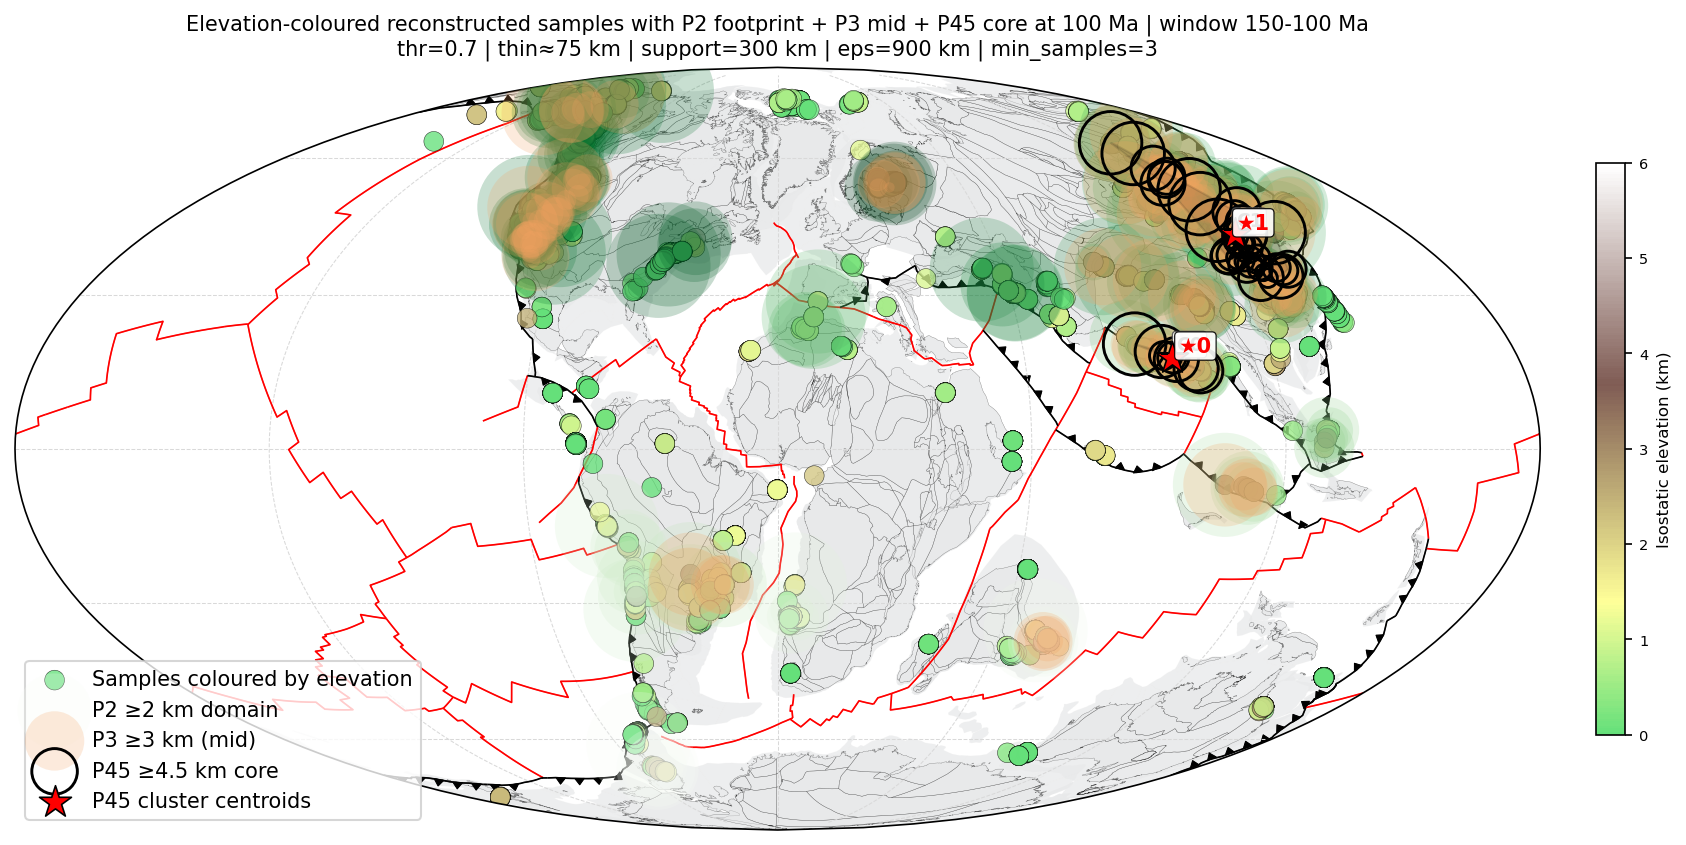

---- Probabilistic Highland Support (mass fractions) ----
Orogenic ≥2 km support:    0.904
Plateau ≥3 km support:     0.870
Extreme ≥4.5 km support:   0.769
   cluster  centroid_lon  centroid_lat  n_points  mean_weight
0        0     95.902539     17.419005         7     0.521429
1        1    130.633723     42.526106        36     0.394012


In [31]:
fig = plt.figure(figsize=(16, 9), dpi=150)
ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
ax.set_global()
ax.gridlines(color="0.85", linestyle="--", linewidth=0.5)

from matplotlib.lines import Line2D

gplot.time = reconstruction_time

# ---------------------------------------------------------------
# 1) Maximum continental extent (main background cue)
# ---------------------------------------------------------------
gplot.plot_continents(
    ax,
    color="0.96",   
    alpha=0.75,            # strong enough to catch the eye first
    linewidth=0.25
)

# thin COB outline
gplot.plot_continent_ocean_boundaries(
    ax,
    facecolor="#e8e9ea",
    linewidth=0.00,
    alpha=0.75,
)

# ---------------------------------------------------------------
# 2) Coastlines on top, but very subtle
# ---------------------------------------------------------------
gplot.plot_coastlines(
    ax,
    facecolor="#e8e9ea",
    linewidth=0.18,
    alpha=0.45,
)

# ---------------------------------------------------------------
# 3) Tectonic features: keep visible but not dominant
# ---------------------------------------------------------------
gplot.plot_ridges_and_transforms(
    ax,
    color="red",
    linewidth=0.6,
    alpha=0.55,
)

gplot.plot_trenches(
    ax,
    color="0.15",
    linewidth=0.55,
    alpha=0.65,
)

gplot.plot_subduction_teeth(
    ax,
    color="0.15",
    linewidth=0.35,
    alpha=0.55,
)

# ---------------------------------------------------------------
# 3) Tectonic features
# ---------------------------------------------------------------
gplot.plot_ridges_and_transforms(ax, color="red", linewidth=0.8)
gplot.plot_trenches(ax, color="k", linewidth=0.8)
gplot.plot_subduction_teeth(ax, color="k", linewidth=0.5)

# ---------------------------------------------------------------
# BASE DOTS: elevation colour-coded
# ---------------------------------------------------------------
if SHOW_ELEVATION_DOTS:
    sc = ax.scatter(
        slice_data["rlon"],
        slice_data["rlat"],
        c=E_mid,
        cmap=elev_cmap,
        vmin=E_VMIN,
        vmax=E_VMAX,
        s=DOT_SIZE,
        alpha=alpha_all,
        edgecolor="k",
        linewidth=DOT_LINEWIDTH,
        transform=ccrs.PlateCarree(),
        zorder=2,
        label="Samples coloured by elevation",
    )

    cbar = fig.colorbar(sc, ax=ax, orientation="vertical", shrink=0.55, pad=0.03)
    cbar.set_label("Isostatic elevation (km)", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

# ---------------------------------------------------------------
# P2 footprint
# ---------------------------------------------------------------
noise_P2 = dbscan_thin_P2["cluster_id_plot"] == -1
clusters_P2 = dbscan_thin_P2.loc[~noise_P2].copy()
sizes_P2 = clusters_P2["spatial_weight"].to_numpy() * 2500

ax.scatter(
    clusters_P2["rlon"], clusters_P2["rlat"],
    s=sizes_P2,
    c=clusters_P2["cluster_id_plot"],
    cmap="Greens",
    alpha=0.22,
    edgecolor="none",
    transform=ccrs.PlateCarree(),
    zorder=3,
    label="P2 ≥2 km domain",
)

# ---------------------------------------------------------------
# P3 mid-layer
# ---------------------------------------------------------------
if SHOW_P3_LAYER:
    noise_P3 = dbscan_thin_P3["cluster_id_plot"] == -1
    clusters_P3 = dbscan_thin_P3.loc[~noise_P3].copy()
    sizes_P3 = clusters_P3["spatial_weight"].to_numpy() * P3_SIZE_SCALE

    ax.scatter(
        clusters_P3["rlon"], clusters_P3["rlat"],
        s=sizes_P3,
        facecolor=P3_COLOR,
        edgecolor="none",
        alpha=P3_ALPHA,
        transform=ccrs.PlateCarree(),
        zorder=4,
        label="P3 ≥3 km (mid)",
    )

    if SHOW_P3_LABELS:
        for cid in sorted(set(clusters_P3["cluster_id_plot"])):
            if cid == -1:
                continue
            pts = clusters_P3[clusters_P3["cluster_id_plot"] == cid]
            if len(pts) < 6:
                continue
            lon_c = pts["rlon"].mean()
            lat_c = pts["rlat"].mean()
            ax.text(
                lon_c + 1.0, lat_c + 0.6,
                f"M{cid}",
                fontsize=8,
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=P3_COLOR, lw=0.8, alpha=0.9),
                transform=ccrs.PlateCarree(),
                zorder=9,
            )

# ---------------------------------------------------------------
# P45 core
# ---------------------------------------------------------------
# METHOD 3 — KDE field
if SHOW_P45_KDE and len(clusters_P45) > 3:
    xy = np.vstack([clusters_P45["rlon"], clusters_P45["rlat"]])
    weights = clusters_P45["spatial_weight"].to_numpy()
    kde = gaussian_kde(xy, weights=weights)

    lon_grid = np.linspace(-180, 180, 240)
    lat_grid = np.linspace(-90, 90, 120)
    xx, yy = np.meshgrid(lon_grid, lat_grid)
    density = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    ax.contourf(
        xx, yy, density,
        levels=6,
        cmap="Greys",
        alpha=0.18,
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

# METHOD 2 — convex hull envelopes
if SHOW_P45_HULLS:
    for cid in sorted(set(clusters_P45["cluster_id_plot"])):
        if cid == -1:
            continue
        pts = clusters_P45[clusters_P45["cluster_id_plot"] == cid]
        if len(pts) < 3:
            continue

        xy = np.vstack([pts["rlon"], pts["rlat"]]).T
        hull = ConvexHull(xy)
        poly = xy[hull.vertices]

        ax.fill(
            poly[:, 0], poly[:, 1],
            facecolor="black",
            alpha=0.12,
            edgecolor="black",
            linewidth=1.0,
            transform=ccrs.PlateCarree(),
            zorder=5,
        )

# METHOD 1 — influence disks
if SHOW_P45_INFLUENCE:
    for _, row in clusters_P45.iterrows():
        ax.scatter(
            row["rlon"], row["rlat"],
            s=eps_km * 14,
            facecolor="black",
            alpha=0.05,
            edgecolor="none",
            transform=ccrs.PlateCarree(),
            zorder=6,
        )

# METHOD 0 — ring nuclei
if SHOW_P45_POINTS:
    sizes_P45 = clusters_P45["spatial_weight"].to_numpy() * 900
    ax.scatter(
        clusters_P45["rlon"], clusters_P45["rlat"],
        s=sizes_P45,
        facecolor="none",
        edgecolor="black",
        linewidth=1.4,
        transform=ccrs.PlateCarree(),
        zorder=7,
        label="P45 ≥4.5 km core",
    )

# ---------------------------------------------------------------
# LABELS FOR P45 CORES
# ---------------------------------------------------------------
label_dx, label_dy = 1.2, 0.8
for cid in sorted(set(clusters_P45["cluster_id_plot"])):
    if cid == -1:
        continue
    pts = clusters_P45[clusters_P45["cluster_id_plot"] == cid]
    lon_c = pts["rlon"].mean()
    lat_c = pts["rlat"].mean()

    ax.text(
        lon_c + label_dx, lat_c + label_dy,
        f"C{cid}",
        transform=ccrs.PlateCarree(),
        fontsize=9,
        weight="bold",
        ha="left",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="0.3",
            linewidth=0.6,
            alpha=0.9,
        ),
        zorder=10,
    )

# ---------------------------------------------------------------
# P45 CLUSTER CENTROIDS (stars)
# ---------------------------------------------------------------
if summary_df is not None and len(summary_df) > 0:
    lon_star = summary_df["centroid_lon"].to_numpy(dtype=float)
    lat_star = summary_df["centroid_lat"].to_numpy(dtype=float)

    lon_star = ((lon_star + 180) % 360) - 180
    mask_star = np.isfinite(lon_star) & np.isfinite(lat_star)

    ax.scatter(
        lon_star[mask_star], lat_star[mask_star],
        marker="*",
        s=260,
        facecolor="red",
        edgecolor="black",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=200,
        label="P45 cluster centroids"
    )

    for _, row in summary_df.iterrows():
        lon = float(row["centroid_lon"])
        lat = float(row["centroid_lat"])
        cid = int(row["cluster"])

        lon = ((lon + 180) % 360) - 180

        if np.isfinite(lon) and np.isfinite(lat):
            ax.text(
                lon + 2.0, lat + 1.2,
                f"★{cid}",
                transform=ccrs.PlateCarree(),
                fontsize=10,
                weight="bold",
                color="red",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="white",
                    ec="black",
                    lw=0.6,
                    alpha=0.9
                ),
                zorder=201
            )

# ---------------------------------------------------------------
# Final figure settings
# ---------------------------------------------------------------
ax.legend(loc="lower left", frameon=True)

ax.set_title(
    f"Elevation-coloured reconstructed samples with P2 footprint + P3 mid + P45 core at {reconstruction_time} Ma | "
    f"window {t_max}-{t_min} Ma\n"
    f"thr={prob_threshold} | thin≈{thin_km} km | support={support_radius_km} km | eps={eps_km} km | min_samples={min_samples}",
    fontsize=10,
)

plot_name = (
    f"DBSCAN_P2P3P45_with_elevationDots_centroids_thr{prob_threshold}_"
    f"{reconstruction_time}Ma_thin{thin_km}_eps{eps_km}_min{min_samples}"
)

# force render before save
fig.canvas.draw()

export_plot(fig, plot_name)
plt.show()

# ===============================================================
# METRICS: probability-aware
# ===============================================================
def prob_mass(mask, P):
    m = np.isfinite(P)
    if np.sum(m) == 0:
        return np.nan
    return np.nansum(P[mask]) / np.nansum(P[m])

print("---- Probabilistic Highland Support (mass fractions) ----")
print(f"Orogenic ≥2 km support:    {prob_mass(oro_definite, P2):.3f}")
print(f"Plateau ≥3 km support:     {prob_mass(plat_definite, P3):.3f}")
print(f"Extreme ≥4.5 km support:   {prob_mass(ext_definite, P45):.3f}")
print(summary_df)

In [32]:
# ===============================================================
# SUMMARISE EACH P45 CLUSTER (tectonic-scale diagnostics)
# ===============================================================
clusters = dbscan_thin_P45.copy()
clusters = clusters[clusters["cluster_id"] != -1]   # remove noise

summary = []

for cid in sorted(clusters["cluster_id"].unique()):
    pts = clusters[clusters["cluster_id"] == cid]

    lon_c = pts["rlon"].mean()
    lat_c = pts["rlat"].mean()

    # spatial scale (max great-circle distance inside cluster)
    coords = np.radians(np.vstack([pts["rlat"], pts["rlon"]]).T)
    tree = BallTree(coords, metric="haversine")
    dist, _ = tree.query(coords, k=len(coords))
    max_span_km = np.nanmax(dist) * earth_radius_km

    summary.append({
        "cluster": cid,
        "centroid_lon": lon_c,
        "centroid_lat": lat_c,
        "n_nodes": len(pts),
        "max_span_km": max_span_km,
        "mean_weight": pts["spatial_weight"].mean()
    })

summary_df = pd.DataFrame(summary).sort_values("max_span_km", ascending=False)

print(summary_df)

   cluster  centroid_lon  centroid_lat  n_nodes  max_span_km  mean_weight
1        1    130.633723     42.526106       36  3401.989689     0.394012
0        0     95.902539     17.419005        7  1631.151906     0.521429


In [33]:
for _, row in summary_df.iterrows():
    ax.plot(
        row["centroid_lon"], row["centroid_lat"],
        marker="*", markersize=10,
        color="red",
        transform=ccrs.PlateCarree(),
        zorder=11
    )

In [34]:
print(summary_df[["cluster", "centroid_lon", "centroid_lat"]].head())

print("n clusters:", len(summary_df))
print("lon min/max:", np.nanmin(summary_df["centroid_lon"]), np.nanmax(summary_df["centroid_lon"]))
print("lat min/max:", np.nanmin(summary_df["centroid_lat"]), np.nanmax(summary_df["centroid_lat"]))
print("any NaN lon:", summary_df["centroid_lon"].isna().any())
print("any NaN lat:", summary_df["centroid_lat"].isna().any())

   cluster  centroid_lon  centroid_lat
1        1    130.633723     42.526106
0        0     95.902539     17.419005
n clusters: 2
lon min/max: 95.9025390000651 130.63372285151635
lat min/max: 17.419005429962425 42.5261056646348
any NaN lon: False
any NaN lat: False


In [196]:
import os
import re
import subprocess
from pathlib import Path

# ------------------------------------------------------------
# USER SETTINGS (adjust if needed)
# ------------------------------------------------------------
image_dir = Path("/Users/jianpingzhou/work/Papers/Geology/Geology/revision/DBSCAN_maps")
output_movie = image_dir / "DBSCAN_evolution.mp4"
fps = 1  # frames per second (try 4–8 depending on speed you want)

# ------------------------------------------------------------
# 1. Collect all PNG files
# ------------------------------------------------------------
files = list(image_dir.glob("DBSCAN_P2P3P45_with_elevationDots_centroids_thr0.3_*Ma_thin75_eps900_min3.png"))

if len(files) == 0:
    raise RuntimeError("No matching PNG files found.")

# ------------------------------------------------------------
# 2. Extract geological age (Ma) from filename
# ------------------------------------------------------------
def extract_age(fp):
    m = re.search(r'_(\d+)Ma_', fp.name)
    if m:
        return int(m.group(1))
    else:
        raise ValueError(f"Could not parse age from {fp.name}")

files_sorted = sorted(files, key=extract_age, reverse=True)  # old → young

print(f"Found {len(files_sorted)} frames")
print("First frame:", files_sorted[0].name)
print("Last frame:", files_sorted[-1].name)

# ------------------------------------------------------------
# 3. Create FFmpeg concat file
# ------------------------------------------------------------
concat_file = image_dir / "ffmpeg_input.txt"

with open(concat_file, "w") as f:
    for fp in files_sorted:
        f.write(f"file '{fp.as_posix()}'\n")

# ------------------------------------------------------------
# 4. Run FFmpeg to generate movie
# ------------------------------------------------------------
ffmpeg_cmd = [
    "ffmpeg",
    "-y",                        # overwrite if exists
    "-r", str(fps),              # playback speed
    "-f", "concat",
    "-safe", "0",
    "-i", str(concat_file),
    "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",  # fix QuickTime dimension issue
    "-c:v", "libx264",
    "-pix_fmt", "yuv420p",
    "-crf", "18",                # high quality
    str(output_movie)
]

print("\nRunning FFmpeg...")
subprocess.run(ffmpeg_cmd, check=True)

print("\nMovie created successfully:")
print(output_movie)

Found 36 frames
First frame: DBSCAN_P2P3P45_with_elevationDots_centroids_thr0.3_1750Ma_thin75_eps900_min3.png
Last frame: DBSCAN_P2P3P45_with_elevationDots_centroids_thr0.3_0Ma_thin75_eps900_min3.png

Running FFmpeg...


ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.6.3.2)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.0.1_4 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60.  8.100 / 60.  8.100
  libavcodec     62. 11.100 / 62. 11.100
  libavformat    62.  3.100 / 62.  3.100
  libavdevice    62.  1.100 / 62.  1.100
  libavfilter    11.  4.100 / 11.  4.100
  libswscale      9.  1.100 /  9.  1.100
  libswresample   6.  1.100 /  6.  1.100
Input #0, concat, from '/Users/jianpingzhou/work/Papers/Geology/Geology/revision/DBSCAN_maps/ffmpeg_input.txt':
  Duration: N/A, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: png, rgba(pc, gbr/unkn


Movie created successfully:
/Users/jianpingzhou/work/Papers/Geology/Geology/revision/DBSCAN_maps/DBSCAN_evolution.mp4


[out#0/mp4 @ 0xbe100c600] video:55062KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.002077%
frame=   36 fps=3.0 q=-1.0 Lsize=   55063KiB time=00:00:34.00 bitrate=13266.9kbits/s speed=2.82x elapsed=0:00:12.05    
[libx264 @ 0xbe1049180] frame I:1     Avg QP: 6.48  size:1761240
[libx264 @ 0xbe1049180] frame P:35    Avg QP:11.79  size:1560612
[libx264 @ 0xbe1049180] mb I  I16..4: 43.2% 41.1% 15.7%
[libx264 @ 0xbe1049180] mb P  I16..4:  7.0%  9.6% 11.8%  P16..4:  2.9%  0.8%  0.7%  0.0%  0.0%    skip:67.3%
[libx264 @ 0xbe1049180] 8x8 transform intra:34.4% inter:15.3%
[libx264 @ 0xbe1049180] coded y,uvDC,uvAC intra: 27.9% 25.7% 21.6% inter: 2.0% 1.0% 0.8%
[libx264 @ 0xbe1049180] i16 v,h,dc,p: 87% 10%  2%  0%
[libx264 @ 0xbe1049180] i8 v,h,dc,ddl,ddr,vr,hd,vl,hu: 42%  9% 44%  1%  1%  1%  1%  1%  1%
[libx264 @ 0xbe1049180] i4 v,h,dc,ddl,ddr,vr,hd,vl,hu: 25% 21% 25%  5%  5%  4%  6%  4%  5%
[libx264 @ 0xbe1049180] i8c dc,h,v,p: 81%  9%  8%  3%
[libx264 @ 0